In [1]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import glob

In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

In [3]:
def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

In [4]:
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

In [29]:
# IC & TO detection
def pi_step_segmentation(force_left, force_right, sampling_rate_pi):
    """
    :param force_left:
    :param force_right:
    :param sampling_rate_pi:
    :return:
    """
    IC_left = pi_ic(force_left, sampling_rate_pi)
    IC_right = pi_ic(force_right, sampling_rate_pi)
    TO_left = pi_to(force_left, IC_left)
    TO_right = pi_to(force_right, IC_right)
    events_dict = {'IC_left': np.array(IC_left[:-1]),
              'IC_right': np.array(IC_right[:-1]),
              'TO_left': np.array(TO_left),
              'TO_right': np.array(TO_right)
    }
    return events_dict

def pi_ic(force_side, sampling_rate):
    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]

    # first IC is when rfd first exceeds 1500 N/s
    
    IC_side=[]
    # next IC of the same side has to be at least 500 ms away (fs/2)
    for i in range(len(rfd_1500)):
        # true IC if increase in force during 0.1 s > 1000 N 
        if force_side[rfd_1500[i]+sampling_rate //10] > (force_side[rfd_1500[i]]+1000):
            # next IC of the same side has to be at least 500 ms away (fs/2)
            if len(IC_side) == 0:
                IC_side.append(rfd_1500[i])
            elif rfd_1500[i] - rfd_1500[i - 1] > sampling_rate // 2:
                IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

def pi_to(force_side, IC_side):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        TO_side.extend(np.argwhere(force_side[IC+1:] == 0)[0] + IC+1)
    return TO_side

In [113]:
pi_ic(force_left, 100)

(array([  30, 1381, 1526, 1599, 1665, 1743, 1949, 2093, 2535, 2674, 2750,
        2826, 2899, 2971, 3038, 3184, 3261, 3479, 3915, 4132, 4204, 4641,
        4925, 5150, 5216, 5514, 5725]),
 array([  30,   31,   32, ..., 5959, 5960, 5989], dtype=int64))

In [6]:
def find_hop(events_dict):
    if events_dict['IC_left'][0]<events_dict['IC_right'][0]:
        first = 'IC_left'
        second = 'IC_right'
    else:
        first = 'IC_right'
        second = 'IC_left'
    for i in range(20):
        if events_dict[first][i+1] < events_dict[second][i]:
            print('found hop at ' + str(i) + '. step '+ first[3:] + ' - index:' + str(events_dict[first][i]))
            return first, i
        elif events_dict[second][i] < events_dict[first][i]:
            print('found hop at ' + str(i) + '. step '+ second[3:] + ' - index: ' + str(events_dict[second][i]))
            return second, i

### Data

In [10]:
files = glob.glob(r'D:\Salzburg\Study1\P01\P01_PI_df\*')

In [11]:
shoe = []
surface = []
speed = []
for file in files:
    shoe.append(file.split('\\')[-1].split('_')[0])
    surface.append(file.split('\\')[-1].split('_')[1])
    speed.append(file.split('\\')[-1].split('_')[2][:-4])
conditions = pd.DataFrame([shoe, surface, speed, files], index = ['shoe', 'surface', 'speed/trial', 'path']).T

In [12]:
conditions

,shoe,surface,speed/trial,path
0,UB,up,9,D:\Salzburg\Study1\P01\P01_PI_df\UB_up_9.csv
1,UB,up,8,D:\Salzburg\Study1\P01\P01_PI_df\UB_up_8.csv
2,UB,up,10,D:\Salzburg\Study1\P01\P01_PI_df\UB_up_10.csv
3,UB,OG,9,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_9.csv
4,UB,OG,8,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_8.csv
5,UB,OG,7,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_7.csv
6,UB,OG,6,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_6.csv
7,UB,OG,5,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_5.csv
8,UB,OG,4,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_4.csv
9,UB,OG,3,D:\Salzburg\Study1\P01\P01_PI_df\UB_OG_3.csv


In [95]:
# load data
sh = 'UB'
sur = 'level'
speed = '9'
p = conditions[(conditions['shoe']==sh) & (conditions['surface']==sur) & (conditions['speed/trial']==speed)]['path']
df = pd.read_csv(p.iloc[0])
p.iloc[0]

'D:\\Salzburg\\Study1\\P01\\P01_PI_df\\UB_level_9.csv'

In [14]:
left, right = separate_sides(df)
force_left = pi_force(left)
force_right = pi_force(right)

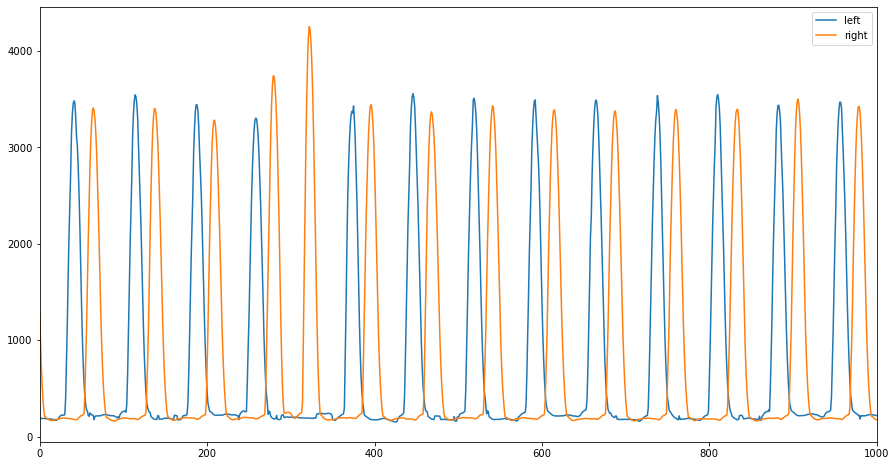

In [15]:
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.xlim(0,1000)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [56]:
def pi_ic(force_side, sampling_rate):
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s
    rfd_1500 = np.where(rfd > 1500)[0]
    # first IC is when rfd first exceeds 1500 N/s
    IC_side=[]
    # next IC of the same side has to be at least 500 ms away (fs/2)
    for i in range(len(rfd_1500)):
        if len(IC_side) == 0:
            if force_side[rfd_1500[i]+ sampling_rate // 10] > (force_side[rfd_1500[i]]+1000):
                IC_side.append(rfd_1500[i])
        elif rfd_1500[i] - rfd_1500[i - 1] > sampling_rate // 4:
            if np.mean(force_side[rfd_1500[i]+ sampling_rate // 10]) > (force_side[rfd_1500[i]]+1000):
                IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

In [84]:
y = list(np.random.rand(5))
print(y)
for x in y:
    if x < 0.5:
        y.remove(x)
        print(x)
print(y)

[0.42228084135848043, 0.9610185033918743, 0.30891693976331747, 0.7028313971118227, 0.5098694701400232]
0.42228084135848043
0.30891693976331747
[0.9610185033918743, 0.7028313971118227, 0.5098694701400232]


In [96]:
def ic (force, fs):
    rfd = np.diff(force, n=1)*fs   # unit N/s
    rfd_1500 = list(np.where(rfd > 1500)[0])
    ic_true=[]
    for IC in rfd_1500:
        if (force[IC+fs//20]) > (force[IC]+1000):
            if len(ic_true) == 0:
                ic_true.append(IC)
            elif IC > ic_true[-1]+fs//4:
                ic_true.append(IC)

    return ic_true

In [112]:
ic_right = ic(force_right, 100)
ic_left = ic(force_left,100)

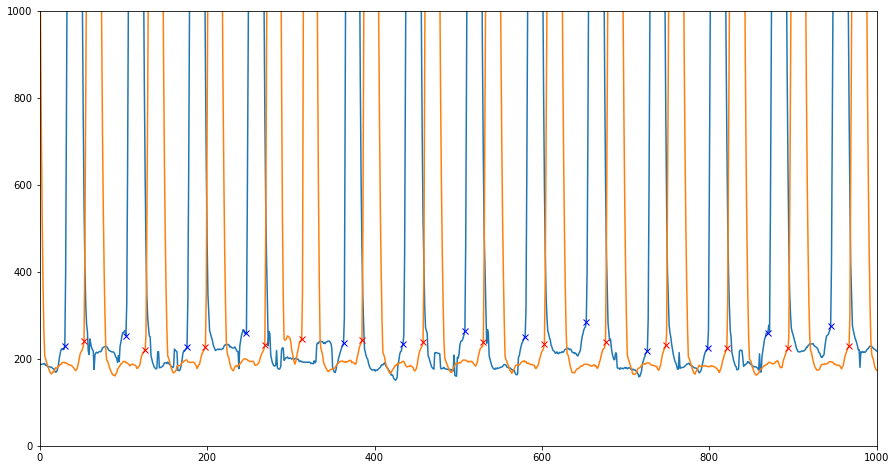

In [114]:
w1=0
w2=w1+1000
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.plot(ic_right, force_right[ic_right], 'rx')
plt.plot(ic_left, force_left[ic_left], 'bx')
plt.xlim(w1,w2)
plt.ylim(-0, 1000)
fig = plt.gcf()
fig.set_size_inches(15, 8)

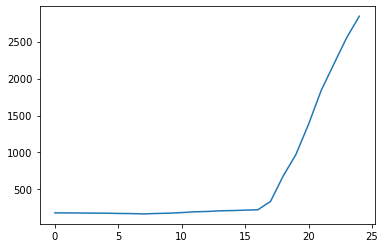

In [80]:
l = 120
rfd = np.diff(force_right, n=1)*100
rfd_1500 = np.where(rfd > 1500)[0]
[rfd_1500[0]]
plt.plot(force_right[rfd_1500[l]-20:rfd_1500[l]+5])

In [95]:
ic_left = pi_ic(force_left, 100)
ic_right = pi_ic(force_right, 100)
events_dict = {'IC_left': ic_left, 'IC_right': ic_right}

In [96]:
find_hop(events_dict)

found hop at 1. step right - index: 126


('IC_right', 1)

In [99]:
ic_left

array([  30, 1381, 1526, 1599, 1743, 2535, 2826, 2899, 2971, 3261, 3479,
       3915, 4132, 4204, 4641, 5150, 5514])

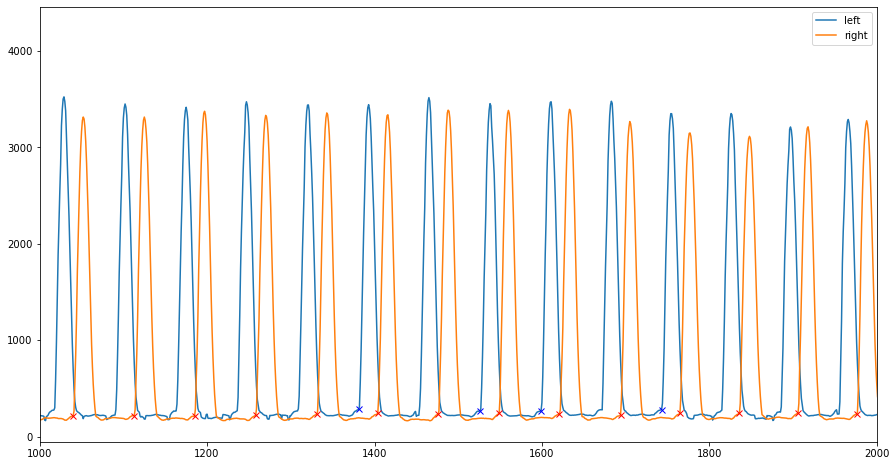

In [114]:
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.plot(ic_right, force_right[ic_right], 'rx')
plt.plot(ic_left, force_left[ic_left], 'bx')
plt.xlim(1000,2000)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [17]:
treadmill = conditions[conditions['surface']!='OG']['path']
i=0

found hop at 3. step right - index: 216


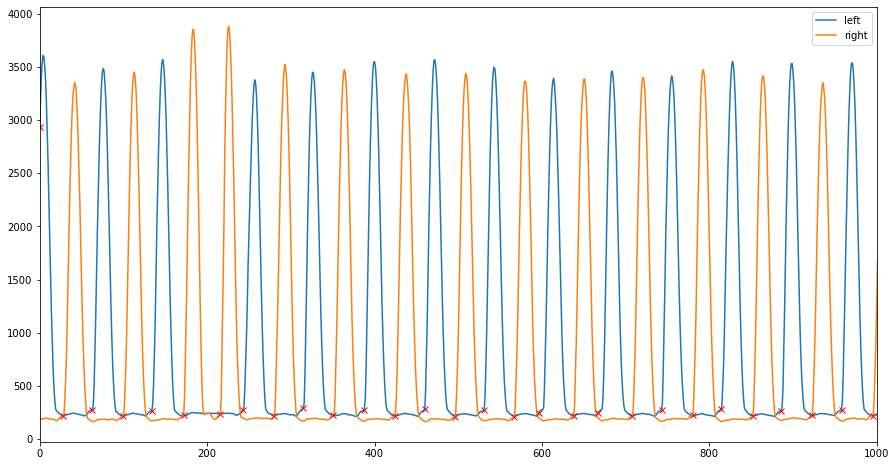

In [18]:
# check all treadmill trials
df = pd.read_csv(treadmill.iloc[i])
left, right = separate_sides(df)
force_left = pi_force(left)
force_right = pi_force(right)
ic_left = pi_ic(force_left, 100)
ic_right = pi_ic(force_right, 100)
events_dict = {'IC_left': ic_left, 'IC_right': ic_right}
find_hop(events_dict)
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.plot(ic_right, force_right[ic_right], 'rx')
plt.plot(ic_left, force_left[ic_left], 'rx')
plt.xlim(0,1000)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

i += 1

In [17]:
pd.DataFrame([ic_right, ic_left], index =['r', 'l'])

,0,1,2,3,4,5,6,7,8,9,...,72,73,74,75,76,77,78,79,80,81
r,53,126,198,269,385,458,530,603,676,748,...,5318.0,5390.0,5462.0,5536.0,5609.0,5681.0,5754.0,5827.0,5900.0,5972.0
l,30,238,427,646,937,1381,1446,1526,1599,1665,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
def find_hop(events_dict):
    if events_dict['IC_left'][0]<events_dict['IC_right'][0]:
        first = 'IC_left'
        second = 'IC_right'
    else:
        first = 'IC_right'
        second = 'IC_left'
    for i in range(20):
        if events_dict[first][i+1] < events_dict[second][i]:
            print('found hop at ' + str(i) + '. step '+ first[3:] + ' - index:' + str(events_dict[first][i]))
            return first, i
        elif events_dict[second][i] < events_dict[first][i]:
            print('found hop at ' + str(i) + '. step '+ second[3:] + ' - index: ' + str(events_dict[second][i]))
            return second, i

## Offset removal

In [79]:
# stage 1: substract minimal pressure image
def offset_stage1(array3):
    offset = array3[:,:,0]
    for frame in range(1,array3.shape[2]):
        if np.sum(offset)>np.sum(array3[:,:,frame]):
            offset = array3[:,:,frame]
    for frame in range(array3.shape[2]):
        array3[:,:,frame]-=offset
    return array3

In [80]:
# stage 0: filter all pressure readings < 1 to 0
def offset_stage0(array3):
    array3[array3<1]=0
    return array3

In [83]:
# stage 2: substract minimal pressure image in last 0.1s  before IC
def offset_stage2(array3, ic, sampling_rate_pi):
    for i in range(len(ic)):
        # minimum of all frames befor first ic
        if i == 0:
            if ic[i] == 0:
                continue
            else:
                array3[:,:,:ic[i]] = offset_stage1(array3[:,:,:ic[i]])
        # minimum between current and previous ic
        else:
            #w1 = ic[i]-(sampling_rate_pi//10)
            array3[:,:,ic[i-1]:ic[i]] = offset_stage1(array3[:,:,ic[i-1]:ic[i]])
    
    return array3
        

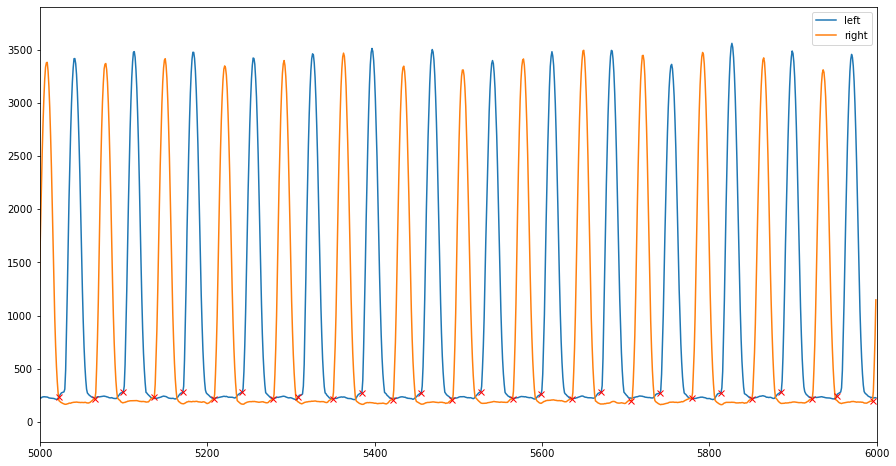

In [95]:
left, right = separate_sides(df)

# stage 0 & 1
l = offset_stage1(offset_stage0(left))
r = offset_stage1(offset_stage0(right))
force_left = pi_force(l)
force_right = pi_force(r)
ic_left = pi_ic(force_left, 100)
ic_right = pi_ic(force_right, 100)

# plot
plt.plot(force_left, label='left')
plt.plot(force_right, label='right')
plt.plot(ic_right, force_right[ic_right], 'rx')
plt.plot(ic_left, force_left[ic_left], 'rx')
plt.xlim(5000,6000)
#plt.ylim(0,400)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

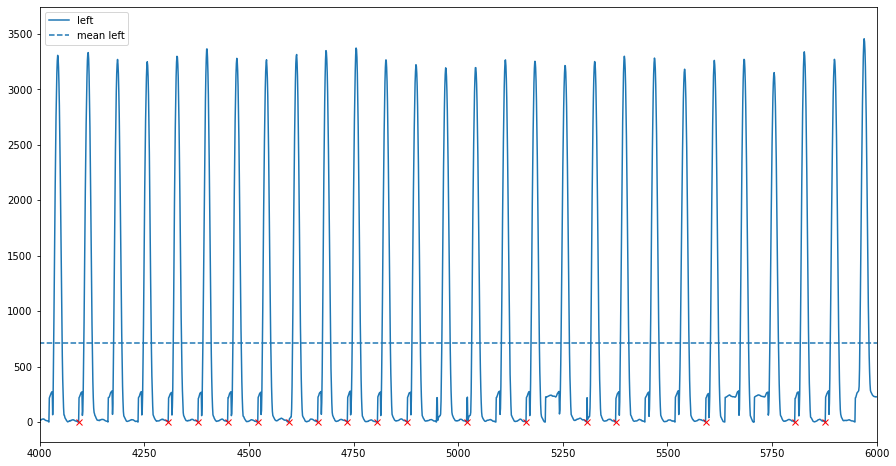

In [104]:
# stage 2
l1 = offset_stage2(l, ic_left, 100)
r1 = offset_stage2(r, ic_right, 100)
force_left1 = pi_force(l1)
force_right1 = pi_force(r1)
ic_left1 = pi_ic(force_left1, 100)
ic_right1 = pi_ic(force_right1, 100)

# plot
plt.plot(force_left1, label='left')
plt.hlines(np.mean(force_left1), 0, 6000, label='mean left', linestyles = '--')
#plt.plot(force_right1, label='right')
#plt.plot(ic_right1, force_right1[ic_right1], 'rx')
plt.plot(ic_left1, force_left1[ic_left1], 'rx')
plt.xlim(4000,6000)
#plt.ylim(0,400)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

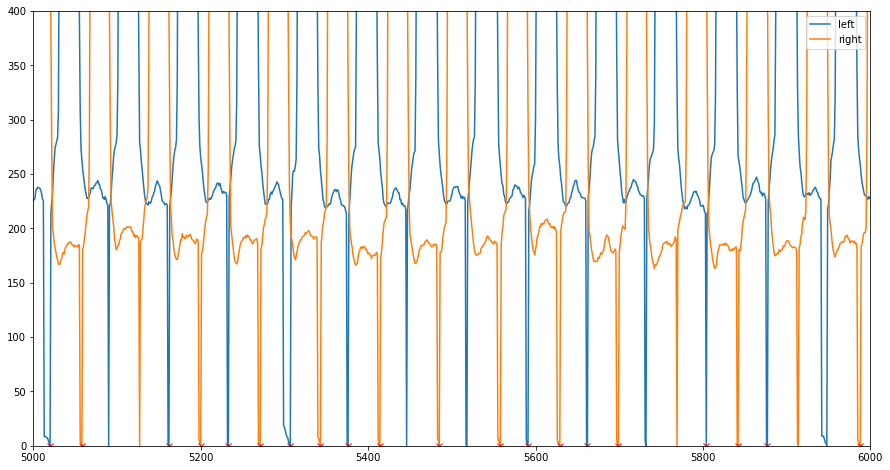

In [88]:
l = offset_stage1(offset_stage0(left))
r = offset_stage1(offset_stage0(right))

force_left = pi_force(l)
force_right = pi_force(r)
ic_left = pi_ic(force_left, 100)
ic_right = pi_ic(force_right, 100)

plt.plot(force_left, label='left')
plt.plot(force_right, label='right')
plt.plot(ic_right, force_right[ic_right], 'rx')
plt.plot(ic_left, force_left[ic_left], 'rx')
plt.xlim(5000,6000)
plt.ylim(0,400)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

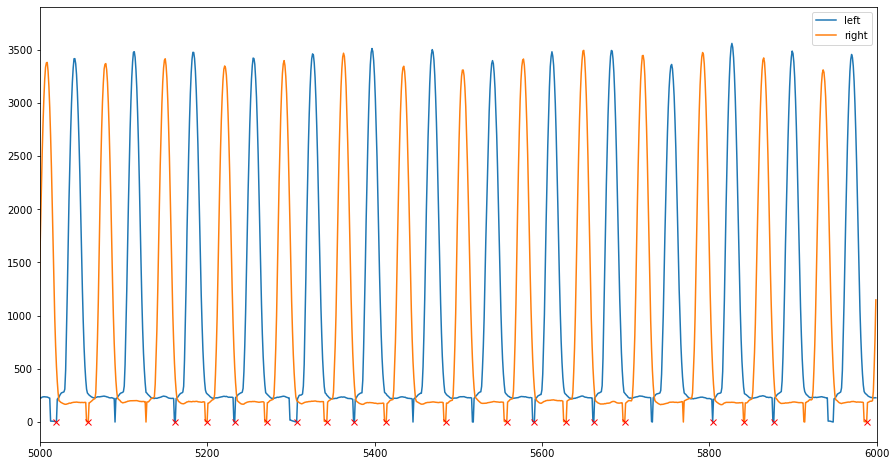

In [91]:
l1 = offset_stage2(l, ic_left, 100)
r1 = offset_stage2(r, ic_right, 100)
force_left1 = pi_force(l1)
force_right1 = pi_force(r1)
ic_left1 = pi_ic(force_left1, 100)
ic_right1 = pi_ic(force_right1, 100)
plt.plot(force_left1, label='left')
plt.plot(force_right1, label='right')
plt.plot(ic_right1, force_right1[ic_right], 'rx')
plt.plot(ic_left1, force_left1[ic_left1], 'rx')
plt.xlim(5000,6000)
#plt.ylim(0,400)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)


In [57]:
r.shape

(31, 11, 6000)

In [50]:
0.1*100

10.0

In [38]:
events_dict=pi_step_segmentation(force_left, force_right, 100)

IndexError: index 0 is out of bounds for axis 0 with size 0